In [1]:
from classy import Class
import numpy as np
import matplotlib.pyplot as plt

$$ \Omega_{tot} = \Omega_b + \Omega_{cdm} + \Omega_{ncdm} + \Omega_{ur} + \Omega_g $$

for later times, when neutrinos have become non-relativistic,

$$\Omega_m = \Omega_b + \Omega_{cdm} + \Omega_{ncdm}$$

In this program, I fix the value of $\Omega_m$ to 0.319 or ~ 32%. Adding new matter species to the universe then eats away at the CDM fraction. 

In Universe 0, we would like to have $\Omega_m = \Omega_{cdm}$. But because of simulation constriants, we actually have that there is still 0.5% baryons. 

In Universe 1, we add baryons in the standard amount, about 5% of matter. This is the standard LCDM universe. 

In Universe 2, we add a single WDM particle of mass 0.06 eV. 

In Universe 3, we change the WDM particle mass to 0.2 eV. So the particle is heavier -> takes up more of energy density -> more suppression. But, suppression starts later than in universe 2 on the x-axis because its free-streaming length is shorter. 


This plot doesn't really match Dodelson, but it could be the result of not using a perfect CDM-only universe. I find that adjusting Omega_b a little bit in Universe 0 can substantially affect the transfer functions. 

In [ ]:
O_m = 0.319


# primarily CDM universe
params_cdm = {
    "output": "mTk, mPk",     # matter transfer function, power spectrum
    "P_k_max_h/Mpc": 10.0,    # max k on the  x-axis, usually 1 
   
   
    "Omega_b": 0.0045,
    "Omega_cdm": O_m - 0.0045, 

    "YHe": 0.25,              # fraction: He mass over baryon mass. 
    "tau_reio": 0.06,         # ?
}

# add baryons (default universe)
params_b_cdm = {
    "output": "mTk, mPk",     
    "P_k_max_h/Mpc": 10.0,    

    "Omega_m": O_m,

    "YHe": 0.25,              
    "tau_reio": 0.06,         
}

# add neutrinos
params_nu_b_cdm = {
    "output": "mTk, mPk",     
    "P_k_max_h/Mpc": 10.0,    

    "N_ncdm": 1,
    "m_ncdm": 0.06,
    "Omega_m": O_m,
    # no ncdm; photons and N_ur included as default values

    "YHe": 0.25,                           
    "tau_reio": 0.06,         
}

# add neutrinos 2
params_nu2_b_cdm = {
    "output": "mTk, mPk",     
    "P_k_max_h/Mpc": 10.0,    

    "N_ncdm": 1,
    "m_ncdm": 0.2,
    "Omega_m": O_m,
    # no ncdm; photons and N_ur included as default values

    "tau_reio": 0.06,         
}

# Initialize and run CLASS
cosmo_cdm = Class()
cosmo_cdm.set(params_cdm)
cosmo_cdm.compute()

cosmo_b_cdm = Class()
cosmo_b_cdm.set(params_b_cdm)
cosmo_b_cdm.compute()

cosmo_nu_b_cdm = Class()
cosmo_nu_b_cdm.set(params_nu_b_cdm)
cosmo_nu_b_cdm.compute()
print(cosmo_nu_b_cdm.Om_ncdm(0))

cosmo_nu2_b_cdm = Class()
cosmo_nu2_b_cdm.set(params_nu2_b_cdm)
cosmo_nu2_b_cdm.compute()




0.0014350665858039427


dict_keys(['k (h/Mpc)', 'd_g', 'd_b', 'd_cdm', 'd_ur', 'd_m', 'd_tot', 'phi', 'psi'])


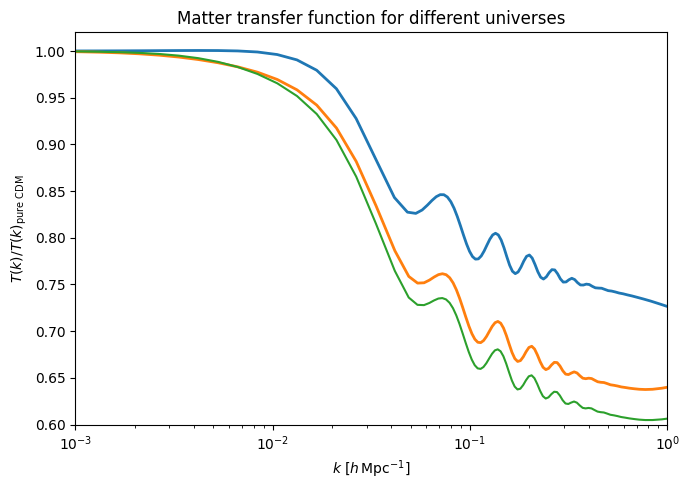

In [26]:
# Total matter transfer function at z=0
tk_cdm = cosmo_cdm.get_transfer(z=0)
print(tk_cdm.keys())
ks_cdm = tk_cdm["k (h/Mpc)"]           
dtot_cdm = tk_cdm["d_tot"]     

tk_b_cdm = cosmo_b_cdm.get_transfer(z=0)
ks_b_cdm = tk_b_cdm["k (h/Mpc)"]           
dtot_b_cdm = tk_b_cdm["d_tot"]     

tk_nu_b_cdm = cosmo_nu_b_cdm.get_transfer(z=0)
ks_nu_b_cdm = tk_nu_b_cdm["k (h/Mpc)"]           
dtot_nu_b_cdm = tk_nu_b_cdm["d_tot"]


tk_nu2_b_cdm = cosmo_nu2_b_cdm.get_transfer(z=0)
ks_nu2_b_cdm = tk_nu2_b_cdm["k (h/Mpc)"]           
dtot_nu2_b_cdm = tk_nu2_b_cdm["d_tot"]  

#??
# Matter transfer function T(k):
T_cdm = np.abs(dtot_cdm) / ks_cdm**2 # on large scales delta_m ~ k^2 * T(k), so define T(k) = delta_m / k^2
T_cdm /= T_cdm[0] # normalize to 1 for the matter era entries

T_b_cdm = np.abs(dtot_b_cdm) / ks_b_cdm**2 # on large scales delta_m ~ k^2 * T(k), so define T(k) = delta_m / k^2
T_b_cdm /= T_b_cdm[0] # normalize to 1 for the matter era entries

T_nu_b_cdm = np.abs(dtot_nu_b_cdm) / ks_nu_b_cdm**2 # on large scales delta_m ~ k^2 * T(k), so define T(k) = delta_m / k^2
T_nu_b_cdm /= T_nu_b_cdm[0] # normalize to 1 for the matter era entries

T_nu2_b_cdm = np.abs(dtot_nu2_b_cdm) / ks_nu2_b_cdm**2 # on large scales delta_m ~ k^2 * T(k), so define T(k) = delta_m / k^2
T_nu2_b_cdm /= T_nu2_b_cdm[0] # normalize to 1 for the matter era entries



# Plot
plt.figure(figsize=(7, 5))
plt.xscale("log")
plt.plot(ks_b_cdm, T_b_cdm / T_cdm, lw=2)
plt.plot(ks_nu_b_cdm, T_nu_b_cdm / T_cdm, lw=2)
plt.plot(ks_nu2_b_cdm, T_nu2_b_cdm / T_cdm)
plt.xlim(1e-3, 1)
plt.ylim(0.6, 1.02)
plt.xlabel(r"$k \ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$T(k) / T(k)_{\text{pure CDM}}$")
plt.title("Matter transfer function for different universes")
plt.tight_layout()
plt.show()
